# QLoRA Training Data Visualization - UNKWORDZ Replacement

This notebook demonstrates the UNKWORDZ word replacement process used for text ablation in language models.
We'll visualize examples of how questions are corrupted by replacing words with 'UNKWORDZ' tokens at different rates.
This approach preserves sequence length while explicitly marking corrupted information.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
# Import our utilities
from qlora_utils import (
    create_binomial_ablated_dataset,
    apply_binomial_ablation,
    load_local_data_for_training
)
from medqa_utils import create_medqa_prompt
from medmcqa_utils import create_medmcqa_prompt

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Load Sample Data

Let's load a small sample of MedQA and MedMCQA data to demonstrate the ablation process.

In [3]:
# Load sample data
print("Loading MedQA sample data...")
medqa_questions = load_local_data_for_training(
    dataset_name="medqa",
    n_samples=1000,
    balanced=True
)

print("Loading MedMCQA sample data...")
medmcqa_questions = load_local_data_for_training(
    dataset_name="medmcqa",
    n_samples=1000,
    balanced=True
)

print(f"Loaded {len(medqa_questions)} MedQA questions")
print(f"Loaded {len(medmcqa_questions)} MedMCQA questions")

Loading MedQA sample data...
Loading balanced MedQA dataset from /home/antonxue/shailesh/MCal/data/language/balanced_dev.jsonl
Loading 1000 samples with balanced distribution:
  Base samples per choice: 200
✓ Loaded 1000 balanced local MedQA questions
  Distribution: {'A': 200, 'B': 200, 'C': 200, 'D': 200, 'E': 200}
Loading MedMCQA sample data...
Loading balanced MedMCQA dataset from /home/antonxue/shailesh/MCal/data/language/dev_balanced.json
Loading 1000 samples with balanced distribution:
  Base samples per choice: 250
✓ Loaded 1000 balanced MedMCQA questions
  Distribution: {'A': 250, 'B': 250, 'C': 250, 'D': 250}
Loaded 1000 MedQA questions
Loaded 1000 MedMCQA questions


## 2. Visualize Original Questions

Let's first look at what the original questions look like before ablation.

In [4]:
def display_question(question_data, dataset_type="medqa"):
    """Display a formatted question."""
    if dataset_type == "medqa":
        prompt = create_medqa_prompt(question_data)
        # Convert answer_idx to int first since it might be stored as string
        answer_idx= question_data['answer_idx']
        answer =  answer_idx # Answer is already a string for medmqa
    else:  # medmcqa
        prompt = create_medmcqa_prompt(question_data)
        answer = chr(65 + int(question_data['cop']) - 1)  # Convert to letter (A, B, C, D)
    
    print(f"Dataset: {dataset_type.upper()}")
    print(f"Correct Answer: {answer}")
    print("\nPrompt:")
    print("-" * 80)
    print(prompt)
    print("-" * 80)
    print()

# Display first example from each dataset
print("=== ORIGINAL QUESTIONS ===")
print()
display_question(medqa_questions[0], "medqa")
display_question(medmcqa_questions[0], "medmcqa")

=== ORIGINAL QUESTIONS ===

Dataset: MEDQA
Correct Answer: C

Prompt:
--------------------------------------------------------------------------------
Question: A medical student is performing clinical research by analyzing the aggregated data of all patients from a national database. In performing the study, she uses all the data collected from patients who had an appendectomy and analyzes the risk factors that are associated with readmission after discharge. She first excludes some of the data based on previously determined exclusion criteria and then performs analysis on the rest. She performs a multiple regression on all variables and finds that one of the risk factors demonstrates a < 5% probability of being the same between groups. She takes this result and presents it to faculty; however, they respond that the finding is meaningless. Which of the following faults to this study most likely explains why the result was considered meaningless?
A. Data should not be excluded from the

## 4. Visualize Ablation Examples

Now let's see how the same question looks with different ablation rates.

In [5]:
def show_ablation_examples(question_data, dataset_type="medqa", ablation_rates=[0.0, 0.2, 0.5, 0.8]):
    """Show the same question with different ablation rates using internal prompt ablation."""
    print(f"=== ABLATION EXAMPLES ({dataset_type.upper()}) ===")
    print()
    
    for rate in ablation_rates:
        if dataset_type == "medqa":
            # Use create_medqa_prompt with removal_fraction parameter
            ablated_prompt = create_medqa_prompt(question_data, removal_fraction=rate)
        else:
            # Use create_medmcqa_prompt with removal_fraction parameter
            ablated_prompt = create_medmcqa_prompt(question_data, removal_fraction=rate)
        
        print(f"Ablation Rate: {rate:.1%}")
        print("-" * 60)
        print(ablated_prompt)
        print("-" * 60)
        print()

# Show examples for both datasets
show_ablation_examples(medqa_questions[0], "medqa")
show_ablation_examples(medmcqa_questions[0], "medmcqa")

=== ABLATION EXAMPLES (MEDQA) ===

Ablation Rate: 0.0%
------------------------------------------------------------
Question: A medical student is performing clinical research by analyzing the aggregated data of all patients from a national database. In performing the study, she uses all the data collected from patients who had an appendectomy and analyzes the risk factors that are associated with readmission after discharge. She first excludes some of the data based on previously determined exclusion criteria and then performs analysis on the rest. She performs a multiple regression on all variables and finds that one of the risk factors demonstrates a < 5% probability of being the same between groups. She takes this result and presents it to faculty; however, they respond that the finding is meaningless. Which of the following faults to this study most likely explains why the result was considered meaningless?
A. Data should not be excluded from the analysis
B. Data should not have b

## 5. Analyze Text Length Changes

Let's quantify how ablation affects text length.

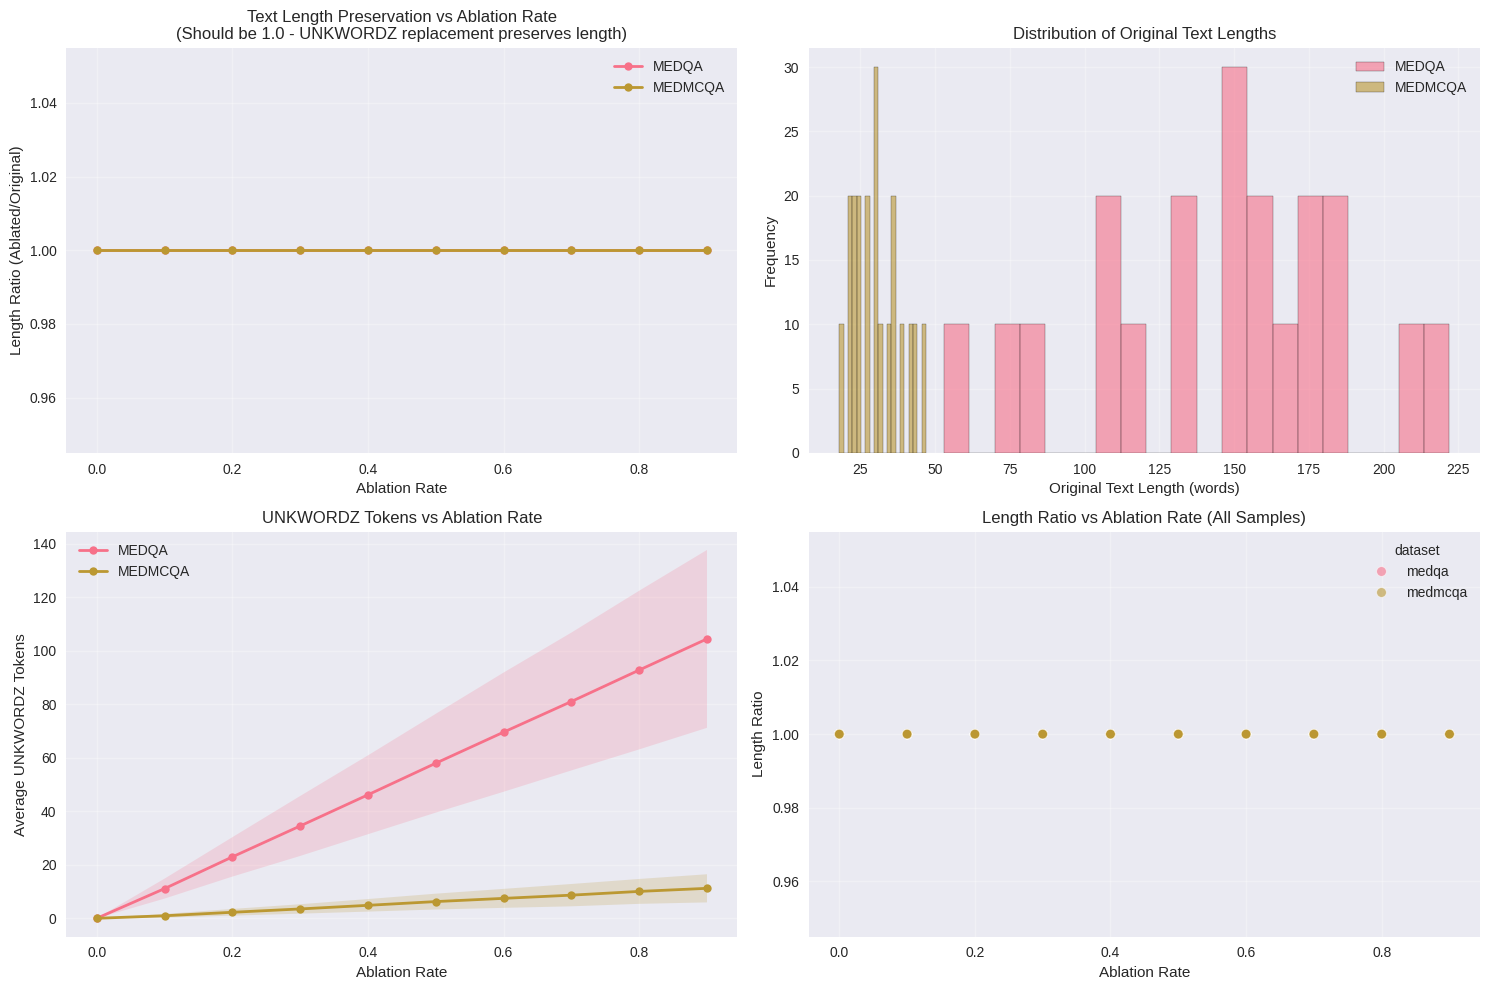

=== LENGTH ANALYSIS SUMMARY ===

MEDQA:
  Average original length: 142.8 words
  Length range: 53-222 words
  Length ratio (should be 1.0): 1.000
  Average UNKWORDZ tokens at 50% ablation: 58.0

MEDMCQA:
  Average original length: 30.4 words
  Length range: 18-47 words
  Length ratio (should be 1.0): 1.000
  Average UNKWORDZ tokens at 50% ablation: 6.2



In [6]:
def analyze_length_changes(questions, dataset_type="medqa", n_examples=20):
    """Analyze how ablation affects text length using internal prompt ablation."""
    ablation_rates = np.linspace(0.0, 0.9, 10)
    length_data = []
    
    for question_data in questions[:n_examples]:
        # Get original prompt (no ablation)
        if dataset_type == "medqa":
            original_prompt = create_medqa_prompt(question_data, removal_fraction=0.0)
        else:
            original_prompt = create_medmcqa_prompt(question_data, removal_fraction=0.0)
        
        original_length = len(original_prompt.split())
        
        for rate in ablation_rates:
            # Get ablated prompt using internal ablation
            if dataset_type == "medqa":
                ablated_prompt = create_medqa_prompt(question_data, removal_fraction=rate)
            else:
                ablated_prompt = create_medmcqa_prompt(question_data, removal_fraction=rate)
                
            ablated_length = len(ablated_prompt.split())
            
            length_data.append({
                'dataset': dataset_type,
                'ablation_rate': rate,
                'original_length': original_length,
                'ablated_length': ablated_length,
                'length_ratio': ablated_length / original_length,
                'words_replaced': ablated_prompt.count('UNKWORDZ')  # Count UNKWORDZ tokens
            })
    
    return pd.DataFrame(length_data)

# Analyze both datasets
medqa_length_df = analyze_length_changes(medqa_questions, "medqa")
medmcqa_length_df = analyze_length_changes(medmcqa_questions, "medmcqa")

# Combine dataframes
all_length_df = pd.concat([medqa_length_df, medmcqa_length_df], ignore_index=True)

# Visualize results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Length ratio vs ablation rate (should be constant at 1.0 since we replace, not remove)
for dataset in ['medqa', 'medmcqa']:
    data = all_length_df[all_length_df['dataset'] == dataset]
    grouped = data.groupby('ablation_rate')['length_ratio'].agg(['mean', 'std']).reset_index()
    ax1.plot(grouped['ablation_rate'], grouped['mean'], 'o-', label=dataset.upper(), linewidth=2, markersize=6)
    ax1.fill_between(grouped['ablation_rate'], 
                     grouped['mean'] - grouped['std'], 
                     grouped['mean'] + grouped['std'], 
                     alpha=0.2)

ax1.set_xlabel('Ablation Rate')
ax1.set_ylabel('Length Ratio (Ablated/Original)')
ax1.set_title('Text Length Preservation vs Ablation Rate\n(Should be 1.0 - UNKWORDZ replacement preserves length)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Original text length distribution
for dataset in ['medqa', 'medmcqa']:
    data = all_length_df[all_length_df['dataset'] == dataset]
    ax2.hist(data['original_length'], bins=20, alpha=0.6, label=dataset.upper(), edgecolor='black')

ax2.set_xlabel('Original Text Length (words)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Original Text Lengths')
ax2.legend()
ax2.grid(True, alpha=0.3)

# UNKWORDZ tokens vs ablation rate
for dataset in ['medqa', 'medmcqa']:
    data = all_length_df[all_length_df['dataset'] == dataset]
    grouped = data.groupby('ablation_rate')['words_replaced'].agg(['mean', 'std']).reset_index()
    ax3.plot(grouped['ablation_rate'], grouped['mean'], 'o-', label=dataset.upper(), linewidth=2, markersize=6)
    ax3.fill_between(grouped['ablation_rate'], 
                     grouped['mean'] - grouped['std'], 
                     grouped['mean'] + grouped['std'], 
                     alpha=0.2)

ax3.set_xlabel('Ablation Rate')
ax3.set_ylabel('Average UNKWORDZ Tokens')
ax3.set_title('UNKWORDZ Tokens vs Ablation Rate')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Scatter plot: ablation rate vs length ratio
sns.scatterplot(data=all_length_df, x='ablation_rate', y='length_ratio', 
                hue='dataset', alpha=0.6, ax=ax4)
ax4.set_xlabel('Ablation Rate')
ax4.set_ylabel('Length Ratio')
ax4.set_title('Length Ratio vs Ablation Rate (All Samples)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== LENGTH ANALYSIS SUMMARY ===")
print()
for dataset in ['medqa', 'medmcqa']:
    data = all_length_df[all_length_df['dataset'] == dataset]
    print(f"{dataset.upper()}:")
    print(f"  Average original length: {data['original_length'].mean():.1f} words")
    print(f"  Length range: {data['original_length'].min()}-{data['original_length'].max()} words")
    print(f"  Length ratio (should be 1.0): {data['length_ratio'].mean():.3f}")
    print(f"  Average UNKWORDZ tokens at 50% ablation: {data[data['ablation_rate']==0.5]['words_replaced'].mean():.1f}")
    print()

## 6. Generate Training Dataset Sample

Let's create a small sample of what the actual training dataset looks like.

In [7]:
# Create a sample training dataset
print("Creating sample training dataset...")
sample_training_data = create_binomial_ablated_dataset(
    questions=medqa_questions[:1000],  # Just 3 questions for demonstration
    p_remove_range=(0.0, 0.9),
    preserve_structure=True,
    seed=42
)

print(f"Generated {len(sample_training_data)} training examples from 3 original questions")
print()

# Display first few training examples
print("=== SAMPLE TRAINING EXAMPLES ===")
print()

for i, example in enumerate(sample_training_data[:5]):
    print(f"Training Example {i+1}:")
    print(f"Ablation Rate: {example['ablation_rate']:.3f}")
    print("Input:")
    print(example['input'][:300] + "..." if len(example['input']) > 300 else example['input'])
    print("\nOutput:")
    print(example['output'])
    print("-" * 80)
    print()

INFO:qlora_utils:Creating binomial ablated dataset with ablation range (0.0, 0.9)
INFO:qlora_utils:Preserve structure: True


Creating sample training dataset...


Creating binomially ablated training data: 100%|██████████| 1000/1000 [00:00<00:00, 40040.71it/s]
INFO:qlora_utils:Created 1000 binomially ablated training examples
INFO:qlora_utils:Ablation rate stats: mean=0.446, std=0.261, min=0.002, max=0.900


Generated 1000 training examples from 3 original questions

=== SAMPLE TRAINING EXAMPLES ===

Training Example 1:
Ablation Rate: 0.575
Input:
Question: is performing clinical all a national In performing she data collected from patients had and analyzes the risk factors She the data based previously criteria and performs analysis on multiple regression all and risk factors < the same takes result and it to they finding is the following to...

Output:
C
--------------------------------------------------------------------------------

Training Example 2:
Ablation Rate: 0.602
Input:
Question: girl to the because of a takes of medical has had frequent nosebleeds in bleeding the and pooled in pharynx. show:

Platelet 195,000/mm3
sec
time
Fibrin
The time minutes. the the most
A. complex concentrate
B. Phytonadione
C. 
D. 
E. Intravenous immunoglobulin
Answer: 

Output:
D
--------------------------------------------------------------------------------

Training Example 3:
Ablation Rate: 0.551

## 7. Training Data Statistics

Let's analyze the distribution of ablation rates in our training data.

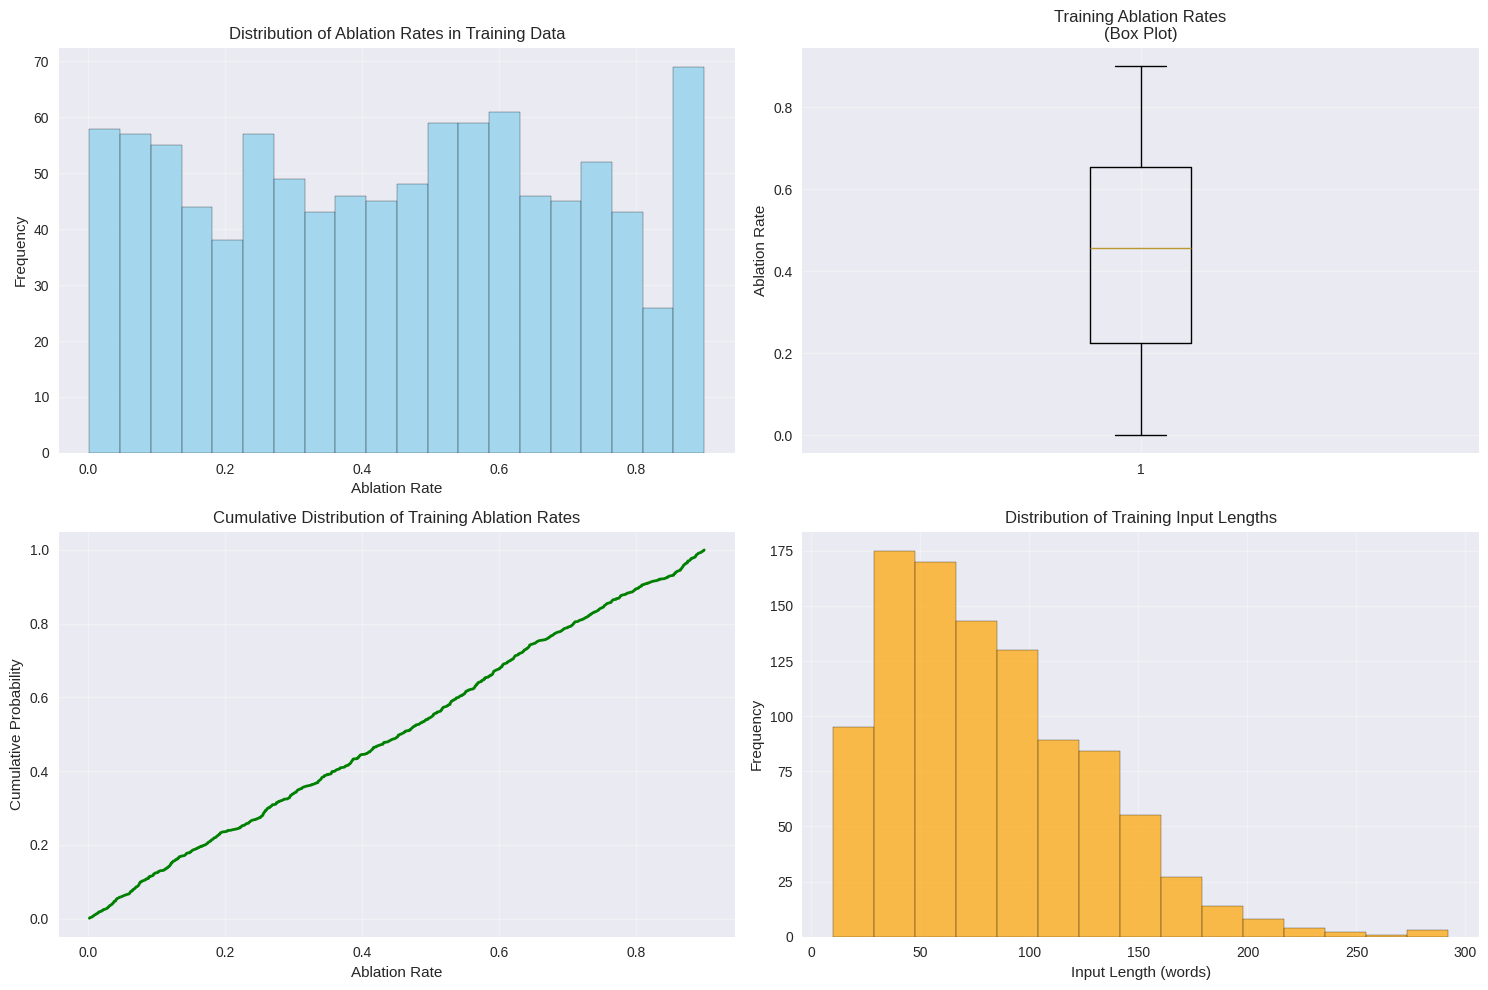

=== TRAINING DATA STATISTICS ===
Total training examples: 1000
Ablation rate - Mean: 0.446
Ablation rate - Std: 0.261
Ablation rate - Min: 0.002
Ablation rate - Max: 0.900
Input length - Mean: 81.9 words
Input length - Range: 10-292 words


In [8]:
# Extract ablation rates from training data
training_ablation_rates = [example['ablation_rate'] for example in sample_training_data]

# Create visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Histogram of training ablation rates
ax1.hist(training_ablation_rates, bins=20, alpha=0.7, edgecolor='black', color='skyblue')
ax1.set_xlabel('Ablation Rate')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Ablation Rates in Training Data')
ax1.grid(True, alpha=0.3)

# Box plot
ax2.boxplot(training_ablation_rates, vert=True)
ax2.set_ylabel('Ablation Rate')
ax2.set_title('Training Ablation Rates\n(Box Plot)')
ax2.grid(True, alpha=0.3)

# Cumulative distribution
sorted_rates = np.sort(training_ablation_rates)
cumulative = np.arange(1, len(sorted_rates) + 1) / len(sorted_rates)
ax3.plot(sorted_rates, cumulative, linewidth=2, color='green')
ax3.set_xlabel('Ablation Rate')
ax3.set_ylabel('Cumulative Probability')
ax3.set_title('Cumulative Distribution of Training Ablation Rates')
ax3.grid(True, alpha=0.3)

# Training example lengths
input_lengths = [len(example['input'].split()) for example in sample_training_data]
ax4.hist(input_lengths, bins=15, alpha=0.7, edgecolor='black', color='orange')
ax4.set_xlabel('Input Length (words)')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Training Input Lengths')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("=== TRAINING DATA STATISTICS ===")
print(f"Total training examples: {len(sample_training_data)}")
print(f"Ablation rate - Mean: {np.mean(training_ablation_rates):.3f}")
print(f"Ablation rate - Std: {np.std(training_ablation_rates):.3f}")
print(f"Ablation rate - Min: {np.min(training_ablation_rates):.3f}")
print(f"Ablation rate - Max: {np.max(training_ablation_rates):.3f}")
print(f"Input length - Mean: {np.mean(input_lengths):.1f} words")
print(f"Input length - Range: {np.min(input_lengths)}-{np.max(input_lengths)} words")

## 8. Compare Ablation Strategies

Let's compare how different ablation strategies affect the same text.

In [9]:
def compare_ablation_strategies(question_data, dataset_type="medqa", ablation_rate=0.5):
    """Compare different ablation strategies on the same question."""
    print(f"=== ABLATION STRATEGY COMPARISON (Rate: {ablation_rate:.1%}) ===")
    print()
    
    # Original (no ablation)
    if dataset_type == "medqa":
        original_prompt = create_medqa_prompt(question_data, removal_fraction=0.0)
        unkwordz_prompt = create_medqa_prompt(question_data, removal_fraction=ablation_rate)
    else:
        original_prompt = create_medmcqa_prompt(question_data, removal_fraction=0.0)
        unkwordz_prompt = create_medmcqa_prompt(question_data, removal_fraction=ablation_rate)
    
    print("ORIGINAL:")
    print("-" * 60)
    print(original_prompt)
    print("-" * 60)
    print()
    
    print("UNKWORDZ REPLACEMENT (Internal Ablation):")
    print("-" * 60)
    print(unkwordz_prompt)
    print("-" * 60)
    print()
    
    # Calculate statistics
    original_words = len(original_prompt.split())
    unkwordz_words = len(unkwordz_prompt.split())
    unkwordz_count = unkwordz_prompt.count('UNKWORDZ')
    
    print("STATISTICS:")
    print(f"Original length: {original_words} words")
    print(f"UNKWORDZ replacement length: {unkwordz_words} words (preserves length)")
    print(f"Number of UNKWORDZ tokens: {unkwordz_count}")
    print(f"Actual replacement rate: {unkwordz_count / original_words:.1%}")
    print(f"Length preservation: {unkwordz_words == original_words}")

# Test with sample questions
print("=== MEDQA EXAMPLE ===")
compare_ablation_strategies(medqa_questions[0], "medqa", 0.3)
print("\n" + "="*80 + "\n")
print("=== MEDMCQA EXAMPLE ===")
compare_ablation_strategies(medmcqa_questions[0], "medmcqa", 0.3)

=== MEDQA EXAMPLE ===
=== ABLATION STRATEGY COMPARISON (Rate: 30.0%) ===

ORIGINAL:
------------------------------------------------------------
Question: A medical student is performing clinical research by analyzing the aggregated data of all patients from a national database. In performing the study, she uses all the data collected from patients who had an appendectomy and analyzes the risk factors that are associated with readmission after discharge. She first excludes some of the data based on previously determined exclusion criteria and then performs analysis on the rest. She performs a multiple regression on all variables and finds that one of the risk factors demonstrates a < 5% probability of being the same between groups. She takes this result and presents it to faculty; however, they respond that the finding is meaningless. Which of the following faults to this study most likely explains why the result was considered meaningless?
A. Data should not be excluded from the analy

## 9. Summary and Key Insights

This notebook demonstrated the QLoRA training data generation process with the following key findings:

In [10]:
print("=== UNKWORDZ REPLACEMENT DATA GENERATION SUMMARY ===")
print()
print("Key Features:")
print("• Word replacement with 'UNKWORDZ' tokens instead of removal")
print("• Ablation rates sampled uniformly from 0-90%")
print("• Text length preservation (unlike token removal)")
print("• Structure preservation maintains question format and answer choices")
print("• Demonstrates word masking approach for text corruption")
print()
print("Benefits of UNKWORDZ Replacement:")
print("• Preserves sequence length (important for transformer models)")
print("• Clear indication of corrupted/missing information")
print("• Maintains text structure and readability")
print("• Allows model to learn explicit corruption patterns")
print("• Easier to analyze and interpret than token removal")
print()
print("Comparison with Other Methods:")
print("• UNKWORDZ replacement: preserves length, explicit corruption markers")
print("• Token removal: reduces length, implicit missing information")
print("• Both methods can be used for training robust language models")
print()
print("Usage for Training:")
print("• Can be integrated into QLoRA training pipeline")
print("• Useful for studying model behavior under different corruption types")
print("• Enables comparison between replacement vs removal strategies")

=== UNKWORDZ REPLACEMENT DATA GENERATION SUMMARY ===

Key Features:
• Word replacement with 'UNKWORDZ' tokens instead of removal
• Ablation rates sampled uniformly from 0-90%
• Text length preservation (unlike token removal)
• Structure preservation maintains question format and answer choices
• Demonstrates word masking approach for text corruption

Benefits of UNKWORDZ Replacement:
• Preserves sequence length (important for transformer models)
• Clear indication of corrupted/missing information
• Maintains text structure and readability
• Allows model to learn explicit corruption patterns
• Easier to analyze and interpret than token removal

Comparison with Other Methods:
• UNKWORDZ replacement: preserves length, explicit corruption markers
• Token removal: reduces length, implicit missing information
• Both methods can be used for training robust language models

Usage for Training:
• Can be integrated into QLoRA training pipeline
• Useful for studying model behavior under different